In [1]:
import time
import ctypes
import numpy as np
from scipy.signal import resample_poly
from scipy.io.wavfile import write as wavwrite
from pynq.overlays.base import BaseOverlay
from pynq.lib import MicroblazeLibrary
from multiprocessing import Process, Manager, Queue
from itertools import takewhile
base = BaseOverlay("base.bit")

In [2]:
%%microblaze base.PMODA
#include <i2c.h>
#include <time.h>
#include <yield.h>
#include <pyprintf.h>

#define DIGILENT_SCL 2
#define DIGILENT_SDA 3
#define CH_0 16
#define CH_1 32
#define CH_0_1 48

#define MAX_SAMPLES 4096

size_t read_idx;
size_t write_idx;
static int samples[MAX_SAMPLES];    

i2c device;

int init_adc() {
    device = i2c_open(DIGILENT_SDA, DIGILENT_SCL);
    unsigned char buf[2];
    buf[0] = CH_0;
    i2c_write(device, 0x28, buf, 1);
    return 0;
}

int read_adc() {
    unsigned char buf[2];
    i2c_read(device, 0x28, buf, 2);
    return ((buf[0] & 0x0F) << 8) | buf[1];
}

int read_adc_multi(size_t size) {
    size_t i;
    unsigned char r[2];
    for (i = 0; i < size; ++i) {
        i2c_read(device, 0x28, r, 2);
        
        samples[i] = ((r[0] & 0x0F) << 8) | r[1];
    }
    
    return 0;
}

// writes samples to the circular buffer
void update_circular() {
    unsigned char r[2];
    while (1) {
        while (((write_idx + 1) % MAX_SAMPLES)
               != (read_idx % MAX_SAMPLES)) {
            i2c_read(device, 0x28, r, 2);
            samples[write_idx] = ((r[0] & 0x0F) << 8) | r[1];
            write_idx = ++write_idx % MAX_SAMPLES;
        }
        yield();
    }
}

int get_circular() {
    int save = 0;
    if (read_idx == write_idx)
    {
        // buffer is empty
        return -1;
    }
    
    save = samples[read_idx++];
    read_idx %= MAX_SAMPLES;
    return save;
}

int get_sample(size_t i) {
    return samples[i];
}

In [3]:
init_adc()
update_circular()

In [4]:
get_circular()

83

In [5]:
start = time.time()
data = [get_circular() for _ in range(4096)]
time.time() - start

4.311710357666016

In [6]:
def audio_stream(queue):
    rv = 0
    stream = [0]
    while True:
        queue.put(get_circular())


In [7]:
buf = []
processed = []
queue = Queue()
p = Process(target=audio_stream, args=(queue,))
p.start() 

In [8]:
queue.get()

82

In [ ]:
CHUNK = 4096  
processed = []

while len(processed) < 200_000:
    read_adc_multi(CHUNK)
    
    chunk = np.array([get_sample(i) for i in range(CHUNK)], dtype=np.float32)
    chunk -= 2048.0
    
    upsampled = resample_poly(chunk, 4, 1).astype(np.int16)
    processed.extend(upsampled)

In [30]:
audio = np.array(processed, dtype=np.float32)

def despike(audio, threshold=3.0):
    mean = np.mean(audio)
    std = np.std(audio)
    spikes = np.abs(audio - mean) > threshold * std
    indices = np.arange(len(audio))
    audio[spikes] = np.interp(indices[spikes], indices[~spikes], audio[~spikes])
    return audio

def normalize(audio):
    peak = np.max(np.abs(audio))
    if peak == 0:
        return audio
    return audio / peak * 32767.0

audio -= np.mean(audio)

audio = despike(audio, threshold=3.0)
audio = normalize(audio)

wavwrite("littlesound.wav", 14_000, audio.astype(np.int16))


In [21]:
p.kill()

In [23]:
max(processed)

-425

In [24]:
min(processed)

-2235

In [25]:
sum(processed) / len(processed)

-1965.238027719351

In [13]:
import matplotlib.pyplot as plt

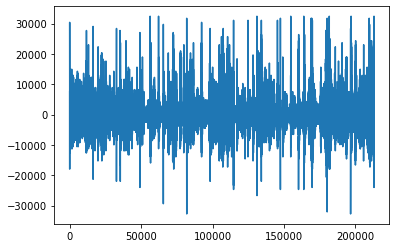

In [31]:
plt.plot(audio)

In [ ]:
t